# Stage 2: Two Coupled Hopf Oscillators

We now introduce **coupling** between two Hopf oscillators connected by a single
edge with weight $w$:

$$\dot{z}_i = z_i(\lambda + i\omega_i - |z_i|^2) + K\tanh\!\left(C\,w\,x_j\right), \qquad i \neq j$$

This is the simplest system where we can compute a **phase-lag index (PLI)** and
study how the coupling strength $K$, excitability $\lambda$, and their ratio
$\kappa = K/\sqrt{\lambda}$ govern synchronization.

### Normalized coupling $\kappa = K / \sqrt{\lambda}$ (as in the paper)

Alexandersen *et al.* rescale the Hopf variables by $\sqrt{\lambda}$ and show that,
for $\lambda > 0$, the **phase dynamics** depend mainly on the **single combination**
$\kappa = K / \sqrt{\lambda}$, not on $K$ and $\lambda$ separately.

**Interpretation (two effects competing):**

- $K$ = strength of **inter-regional** coupling (network pulls regions together).
- $\lambda$ sets the **intraregional** Hopf dynamics; for $\lambda > 0$ the uncoupled limit cycle has radius $\sqrt{\lambda}$, so $\sqrt{\lambda}$ is a natural amplitude scale.

So $\kappa$ is **coupling strength measured in units of that local amplitude scale** — “how strong is the network input *relative to* how big the local oscillation is?”

**What the paper uses it for:** They grid-search $K$ and $\lambda$, then show that **goodness of fit** (Pearson correlation of PLI matrices to MEG data) is **almost unchanged** along curves $K \propto \sqrt{\lambda}$ — i.e. along **constant $\kappa$**. They then compare **optimal $\kappa$** between glioma patients and controls (patients tend to have **higher** normalized coupling). In this notebook we only have two nodes, so we plot **PLI(1,2)** instead of a full matrix correlation, but the same $\kappa$ lines illustrate the same scaling idea.

### Important: PLI measures phase *asymmetry*, not synchronization

$$\mathrm{PLI}_{ij} = \left|\left\langle \operatorname{sign}(\sin(\theta_i - \theta_j)) \right\rangle_t\right|$$

- If two oscillators have **identical** frequencies and no coupling, their phase
  difference is constant (set by ICs) $\Rightarrow$ PLI $\approx 1$. Coupling then
  drives them **in-phase** ($\Delta\theta \to 0$), which *reduces* PLI.
- If they have **different** frequencies and no coupling, the phase difference
  drifts linearly $\Rightarrow$ PLI $\approx 0$. Coupling creates a consistent
  phase lag $\Rightarrow$ PLI *increases*.

The paper uses 78 regions with **different** natural frequencies, so we default to
slightly different frequencies (9.5 Hz and 10.5 Hz) throughout this notebook.

### Goals
1. Visualise time series of two coupled oscillators
2. Sweep $K$ to find the synchronization transition (PLI vs $K$)
3. Build a 2-D heatmap of PLI over the $(K, \lambda)$ parameter space
4. Verify the scaling law $K \sim \sqrt{\lambda}$ on log-log axes
5. Collapse PLI onto a single curve via $\kappa = K/\sqrt{\lambda}$
6. Explore the effect of frequency detuning ($\omega_1 \neq \omega_2$)
7. Explore the effect of edge weight $w$
8. Quantify variability over random initial conditions

In [23]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if not (ROOT / "src" / "hopf_model.py").exists():
    ROOT = ROOT.parent
sys.path.append(str(ROOT / "src"))

FIG_DIR = ROOT / "figures" / "hopf model" / "two node"
FIG_DIR.mkdir(parents=True, exist_ok=True)

from hopf_model import random_initial_conditions, simulate_hopf
from signal_processing import compute_phase, compute_pli

%matplotlib inline
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

## Helpers

In [24]:
DEFAULT_FREQ = (9.5, 10.5)  # Hz -- different frequencies within alpha band

def simulate_two_node(K, lam, omega_hz=DEFAULT_FREQ, w=1.0, C=20.0,
                      z0=None, t_total=14.5, t_discard=1.0, fs=1250):
    """Simulate two coupled Hopf oscillators."""
    N = 2
    W = np.array([[0.0, w], [w, 0.0]])
    omega = 2 * np.pi * np.array(omega_hz)
    if z0 is None:
        z0 = random_initial_conditions(N, rng=42)
    t, x, y = simulate_hopf(N, W, K, lam, C, omega, z0,
                            t_total=t_total, t_discard=t_discard, fs=fs)
    return t, x, y


def pli_from_signals(x, fs=1250):
    """Compute PLI matrix from simulated real-part signals."""
    phases = compute_phase(x, fs)
    return compute_pli(phases)


def pli_12(K, lam, **kwargs):
    """Return the scalar PLI between node 1 and node 2."""
    t, x, y = simulate_two_node(K, lam, **kwargs)
    pli = pli_from_signals(x)
    return pli[0, 1]

## 1. Coupling regimes: no, weak, and strong coupling

We compare three coupling strengths ($K = 0, 5, 20$) across two frequency
configurations (identical vs different $\omega$). This shows:

- **Identical $\omega$**: uncoupled oscillators already have a constant phase
  offset (high PLI). Coupling drives them in-phase, *reducing* PLI.
- **Different $\omega$**: uncoupled oscillators drift apart (low PLI).
  Coupling creates a consistent phase lag, *increasing* PLI.

Each panel annotates the resulting PLI value.

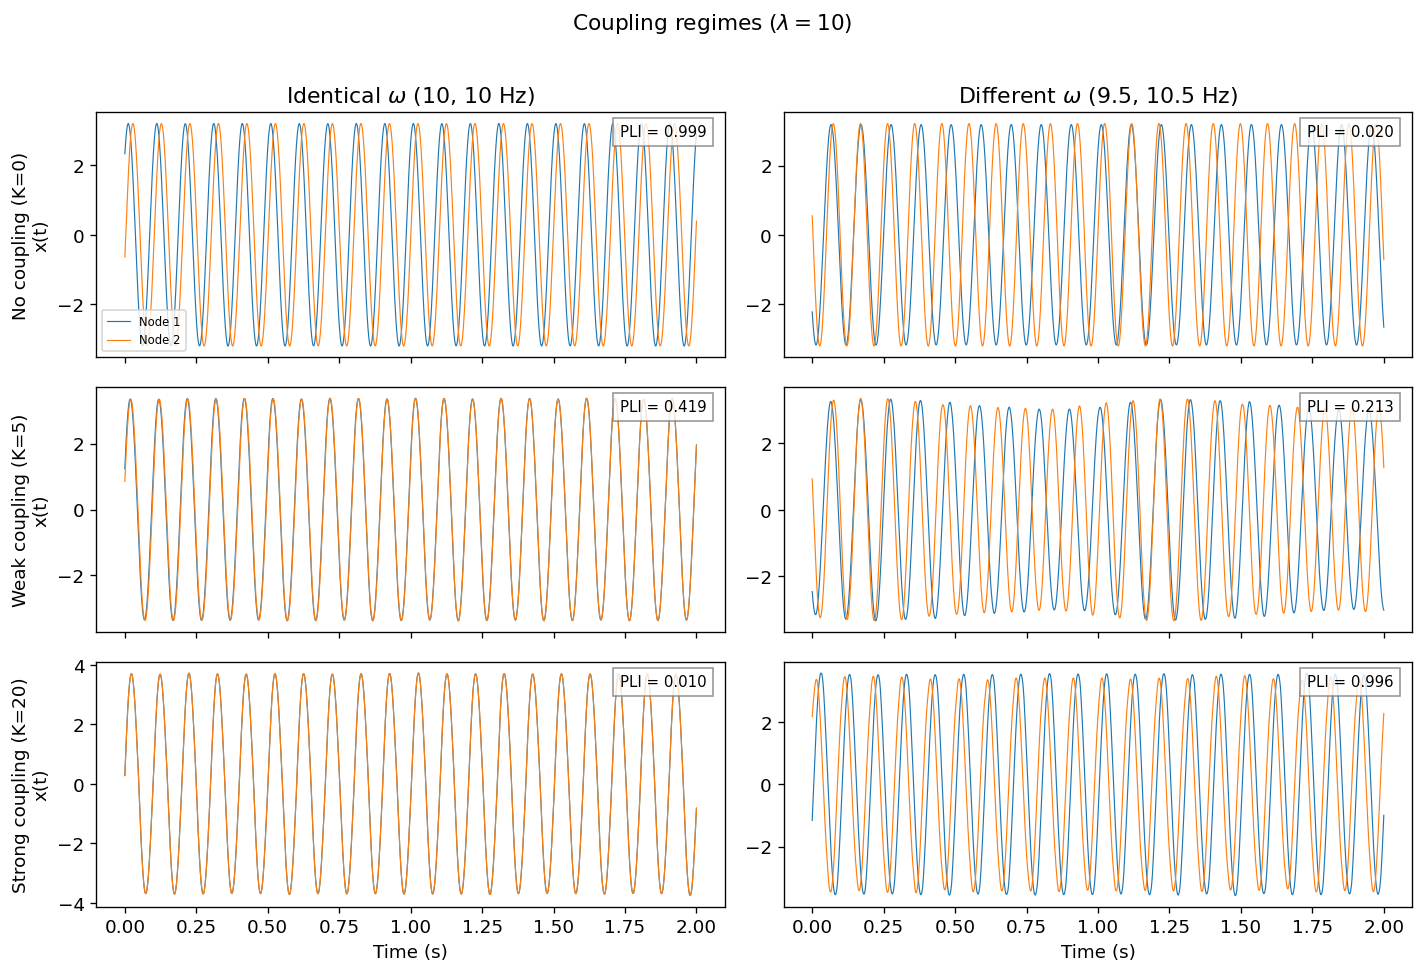

In [25]:
lam = 10.0
K_levels = [0.0, 5.0, 20.0]
K_labels = ["No coupling (K=0)", "Weak coupling (K=5)", "Strong coupling (K=20)"]
freq_configs = [(10.0, 10.0), (9.5, 10.5)]
freq_labels = [r"Identical $\omega$ (10, 10 Hz)", r"Different $\omega$ (9.5, 10.5 Hz)"]

fig, axes = plt.subplots(3, 2, figsize=(12, 8), sharex=True)
win_sec = 2.0

for row, (K, K_lab) in enumerate(zip(K_levels, K_labels)):
    for col, (freqs, f_lab) in enumerate(zip(freq_configs, freq_labels)):
        ax = axes[row, col]
        t, x, y_ = simulate_two_node(K, lam, omega_hz=freqs)
        win = t <= win_sec

        ax.plot(t[win], x[0][win], lw=0.7, label="Node 1")
        ax.plot(t[win], x[1][win], lw=0.7, label="Node 2")

        phases = compute_phase(x, 1250)
        pli_val = compute_pli(phases)[0, 1]
        ax.text(0.97, 0.95, f"PLI = {pli_val:.3f}",
                transform=ax.transAxes, ha="right", va="top",
                fontsize=9, bbox=dict(fc="white", ec="grey", alpha=0.8))

        if row == 0:
            ax.set_title(f_lab)
        if col == 0:
            ax.set_ylabel(f"{K_lab}\nx(t)")
        if row == 2:
            ax.set_xlabel("Time (s)")
        if row == 0 and col == 0:
            ax.legend(fontsize=7, loc="lower left")

fig.suptitle(r"Coupling regimes ($\lambda = 10$)", y=1.01, fontsize=13)
fig.tight_layout()
fig.savefig(FIG_DIR / "01_coupling_regimes_timeseries.png", dpi=150, bbox_inches="tight")


## 2. Phase difference reveals locking

We plot the phase difference $\Delta\theta(t) = \theta_1(t) - \theta_2(t)$
(wrapped to $[-\pi, \pi]$) for the same 3x2 grid as section 1.

- **Identical $\omega$, no coupling**: constant offset (set by ICs).
  Coupling pulls $\Delta\theta \to 0$ (in-phase), destroying the lag.
- **Different $\omega$, no coupling**: $\Delta\theta$ drifts linearly (sawtooth).
  Coupling arrests the drift and locks $\Delta\theta$ to a constant value.

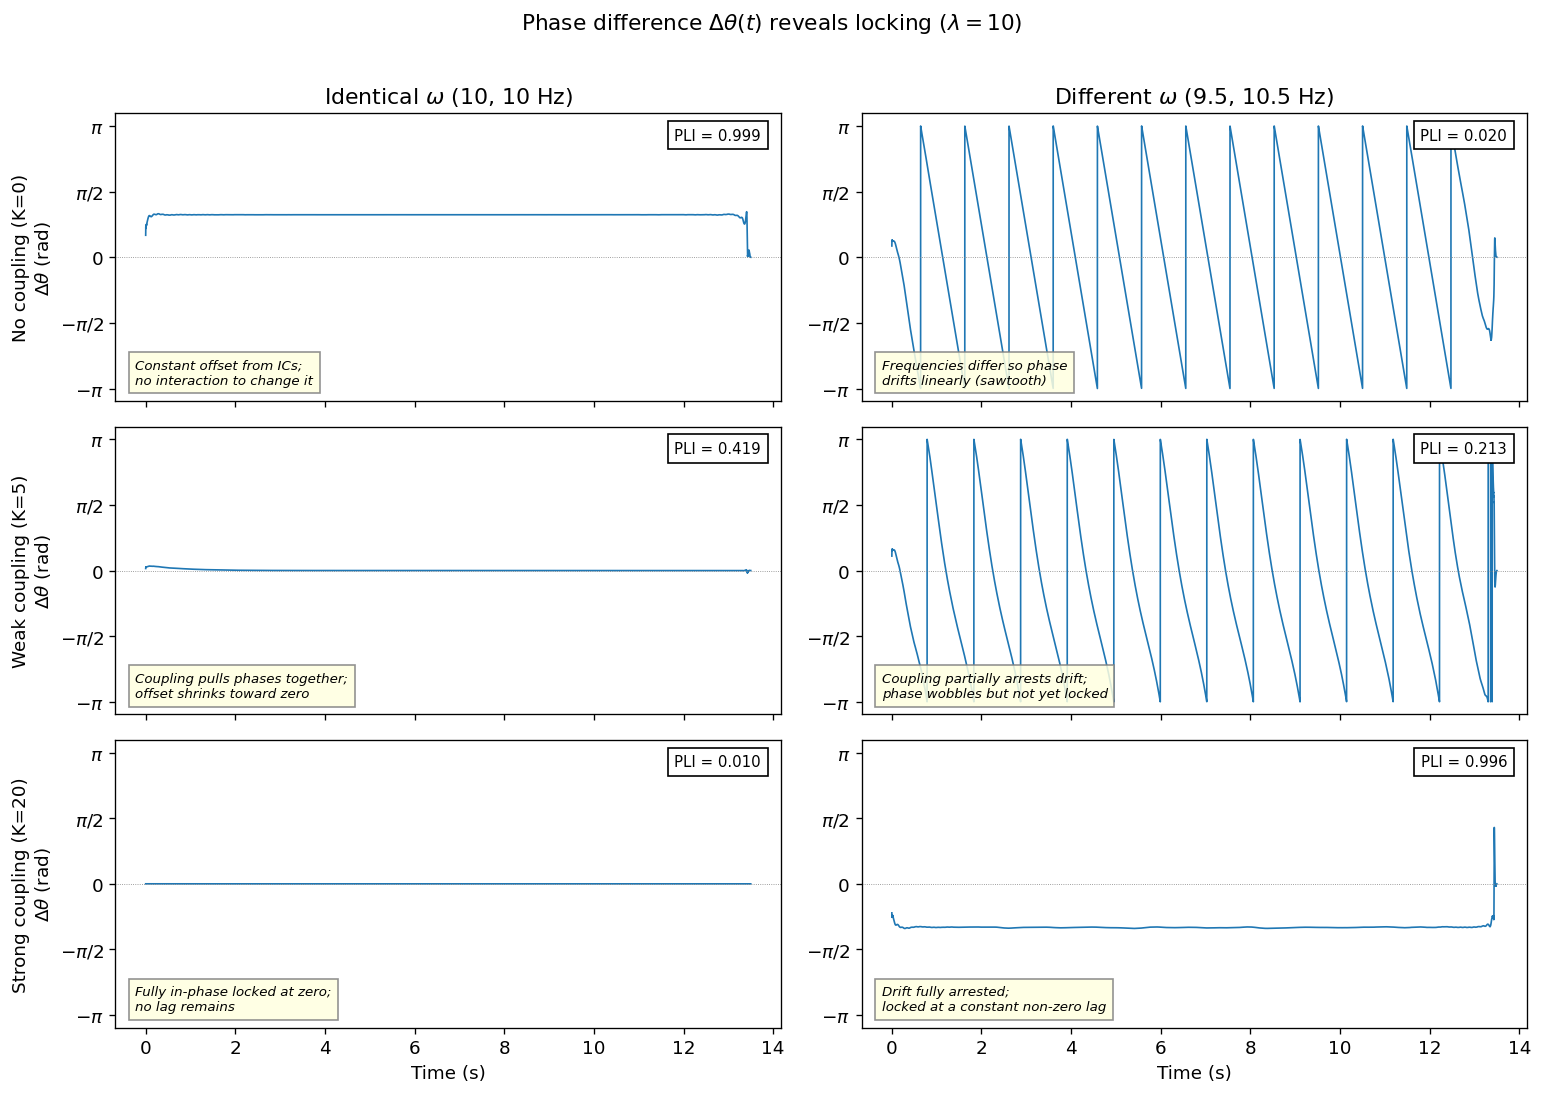

In [26]:
lam = 10.0
K_levels = [0.0, 5.0, 20.0]
K_labels = ["No coupling (K=0)", "Weak coupling (K=5)", "Strong coupling (K=20)"]
freq_configs = [(10.0, 10.0), (9.5, 10.5)]
freq_labels = [r"Identical $\omega$ (10, 10 Hz)", r"Different $\omega$ (9.5, 10.5 Hz)"]

explanations = {
    (0, 0): "Constant offset from ICs;\nno interaction to change it",
    (0, 1): "Frequencies differ so phase\ndrifts linearly (sawtooth)",
    (1, 0): "Coupling pulls phases together;\noffset shrinks toward zero",
    (1, 1): "Coupling partially arrests drift;\nphase wobbles but not yet locked",
    (2, 0): "Fully in-phase locked at zero;\nno lag remains",
    (2, 1): "Drift fully arrested;\nlocked at a constant non-zero lag",
}

def wrap_angle(a):
    return (a + np.pi) % (2 * np.pi) - np.pi

fig, axes = plt.subplots(3, 2, figsize=(13, 9), sharex=True)

for row, (K, K_lab) in enumerate(zip(K_levels, K_labels)):
    for col, (freqs, f_lab) in enumerate(zip(freq_configs, freq_labels)):
        ax = axes[row, col]
        t, x, y_ = simulate_two_node(K, lam, omega_hz=freqs)

        phases = compute_phase(x, 1250)
        delta_theta = wrap_angle(phases[0] - phases[1])

        ax.plot(t, delta_theta, lw=1, color="C0")
        ax.axhline(0, color="grey", ls=":", lw=0.5)
        ax.set_ylim(-np.pi - 0.3, np.pi + 0.3)
        ax.set_yticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
        ax.set_yticklabels([r"$-\pi$", r"$-\pi/2$", "0", r"$\pi/2$", r"$\pi$"])

        pli_val = compute_pli(phases)[0, 1]
        ax.text(0.97, 0.95, f"PLI = {pli_val:.3f}",
                transform=ax.transAxes, ha="right", va="top",
                fontsize=9, bbox=dict(fc="white", ec="black", alpha=1))

        ax.text(0.03, 0.05, explanations[(row, col)],
                transform=ax.transAxes, ha="left", va="bottom",
                fontsize=8, style="italic",
                bbox=dict(fc="lightyellow", ec="grey", alpha=0.85))

        if row == 0:
            ax.set_title(f_lab)
        if col == 0:
            ax.set_ylabel(f"{K_lab}\n" + r"$\Delta\theta$ (rad)")
        if row == 2:
            ax.set_xlabel("Time (s)")

fig.suptitle(r"Phase difference $\Delta\theta(t)$ reveals locking ($\lambda = 10$)",
             y=1.01, fontsize=13)
fig.tight_layout()
fig.savefig(FIG_DIR / "02_phase_difference.png", dpi=150, bbox_inches="tight")


## 3. Synchronization transition: PLI vs coupling strength $K$

Fixing $\lambda = 10$, we sweep $K$ from 0 to 30 and measure PLI.
With different natural frequencies, we expect PLI $\approx 0$ at low $K$
(drifting phase) and increasing PLI as coupling creates a consistent phase lag.

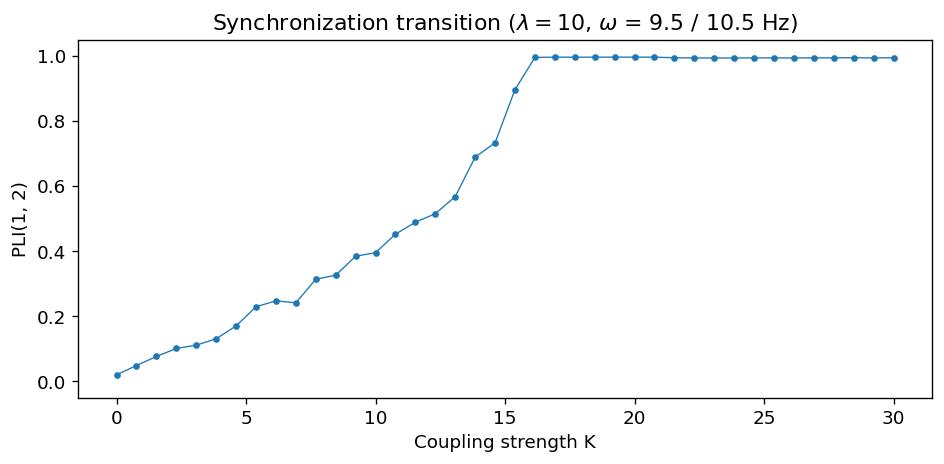

In [27]:
lam = 10.0
K_values = np.linspace(0, 30, 40)
pli_values = [pli_12(K, lam) for K in K_values]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(K_values, pli_values, "o-", ms=3, lw=0.8)
ax.set_xlabel("Coupling strength K")
ax.set_ylabel("PLI(1, 2)")
ax.set_title(r"Synchronization transition ($\lambda = 10$, $\omega$ = 9.5 / 10.5 Hz)")
ax.set_ylim(-0.05, 1.05)
fig.tight_layout()
fig.savefig(FIG_DIR / "03_pli_vs_K.png", dpi=150, bbox_inches="tight")


## 4. PLI heatmap over $(K, \lambda)$

This is the two-node analogue of the paper's Figure 2D. We build a 2-D grid
of PLI values, showing how the interplay of coupling and excitability
determines synchronization.

*(This cell computes a 30x30 grid — takes a few minutes.)*

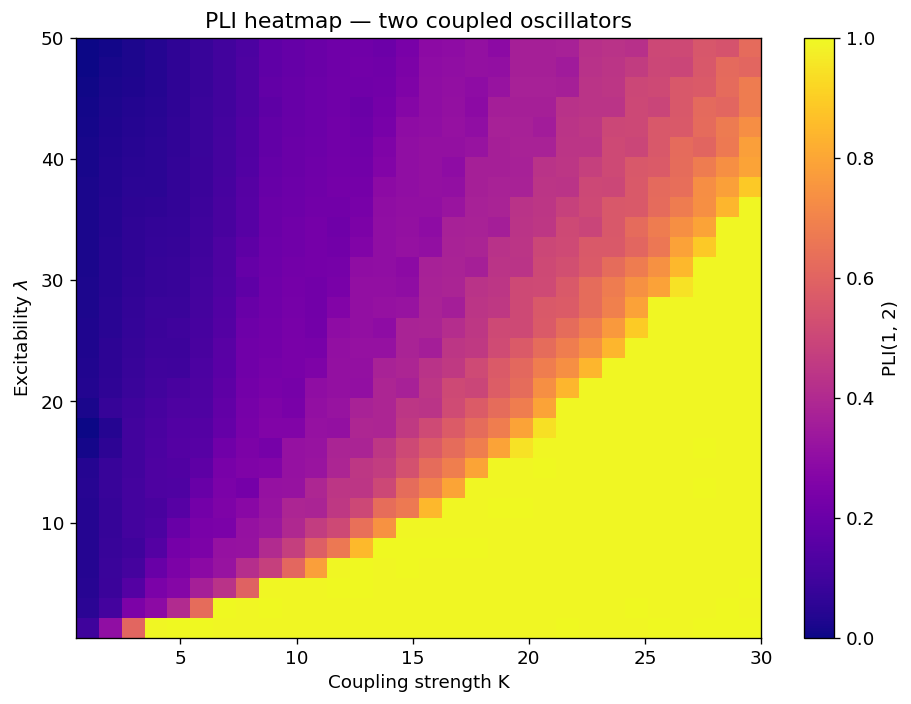

In [28]:
K_grid = np.linspace(0.5, 30, 30)
lam_grid = np.linspace(0.5, 50, 30)
pli_map = np.zeros((len(lam_grid), len(K_grid)))

for i, lam in enumerate(lam_grid):
    for j, K in enumerate(K_grid):
        pli_map[i, j] = pli_12(K, lam)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(pli_map, origin="lower", aspect="auto",
               extent=[K_grid[0], K_grid[-1], lam_grid[0], lam_grid[-1]],
               cmap="plasma", vmin=0, vmax=1)
fig.colorbar(im, ax=ax, label="PLI(1, 2)")
ax.set_xlabel("Coupling strength K")
ax.set_ylabel(r"Excitability $\lambda$")
ax.set_title("PLI heatmap — two coupled oscillators")
fig.tight_layout()
fig.savefig(FIG_DIR / "04_pli_heatmap_K_lambda.png", dpi=150, bbox_inches="tight")


## 5. Scaling law verification on log-log axes

On log–log axes, a relation $K = \kappa\sqrt{\lambda}$ is a **straight line**
with slope $\tfrac{1}{2}$ (because $\log K = \log\kappa + \tfrac{1}{2}\log\lambda$).
The paper shows that **PLI-based** fit contours run along such lines: **phase
statistics are (approximately) constant along constant $\kappa$**. Here we overlay
several choices of $\kappa$ in white.

*(This cell computes a 35x35 grid — takes a few minutes.)*

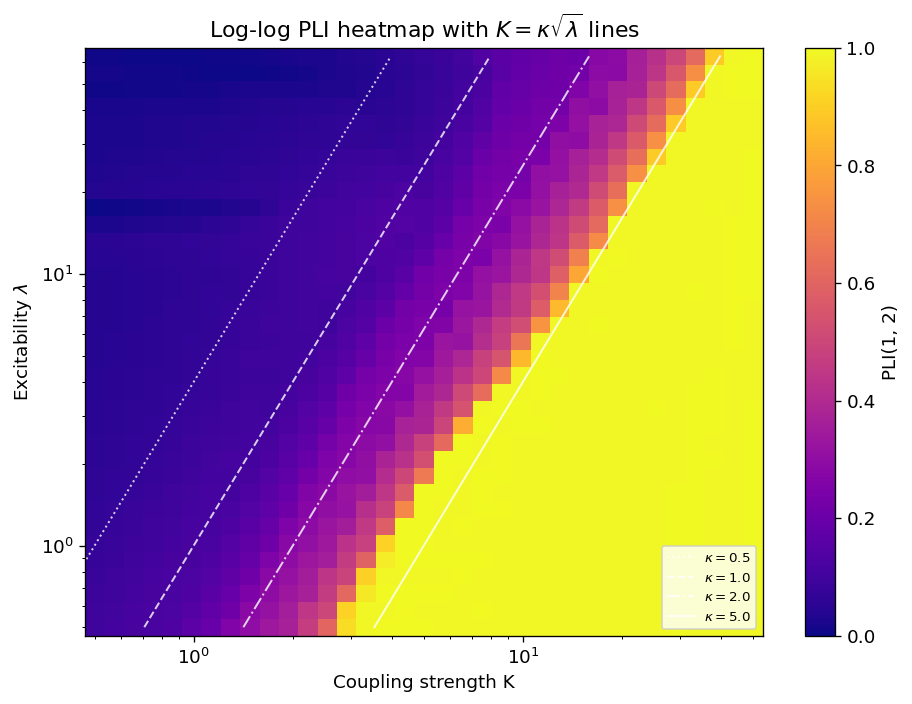

In [29]:
K_log = np.logspace(-0.3, 1.7, 35)
lam_log = np.logspace(-0.3, 1.8, 35)
pli_log = np.zeros((len(lam_log), len(K_log)))

for i, lam in enumerate(lam_log):
    for j, K in enumerate(K_log):
        pli_log[i, j] = pli_12(K, lam)


def _log_bin_edges(centers):
    """Geometric bin edges so pcolormesh fills from first to last log-spaced sample."""
    c = np.asarray(centers, dtype=float)
    lo = c[0] / np.sqrt(c[1] / c[0])
    hi = c[-1] * np.sqrt(c[-1] / c[-2])
    between = np.sqrt(c[:-1] * c[1:])
    return np.concatenate([[lo], between, [hi]])


K_edges = _log_bin_edges(K_log)
lam_edges = _log_bin_edges(lam_log)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.pcolormesh(K_edges, lam_edges, pli_log, cmap="plasma",
                   shading="flat", vmin=0, vmax=1)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(K_edges[0], K_edges[-1])
ax.set_ylim(lam_edges[0], lam_edges[-1])
ax.margins(0)

lam_line = np.logspace(-0.3, 1.8, 100)
for kappa, ls in zip([0.5, 1.0, 2.0, 5.0], [":", "--", "-.", "-"]):
    ax.plot(kappa * np.sqrt(lam_line), lam_line,
            color="white", ls=ls, lw=1.2, alpha=0.8,
            label=rf"$\kappa = {kappa}$")

fig.colorbar(im, ax=ax, label="PLI(1, 2)")
ax.set_xlabel("Coupling strength K")
ax.set_ylabel(r"Excitability $\lambda$")
ax.set_title(r"Log-log PLI heatmap with $K = \kappa\sqrt{\lambda}$ lines")
ax.legend(fontsize=8, loc="lower right")
fig.tight_layout()
# tight_layout can re-expand limits — pin again so the heatmap fills the box
ax.set_xlim(K_edges[0], K_edges[-1])
ax.set_ylim(lam_edges[0], lam_edges[-1])
ax.margins(0)
fig.savefig(FIG_DIR / "05_pli_loglog_heatmap.png", dpi=150, bbox_inches="tight")


## 6. PLI vs normalized coupling $\kappa = K / \sqrt{\lambda}$

If the scaling law holds, PLI should **mostly** collapse onto one curve when
plotted against $\kappa$ (exact overlap is best at larger $\lambda$, as in the paper's log–log figures).

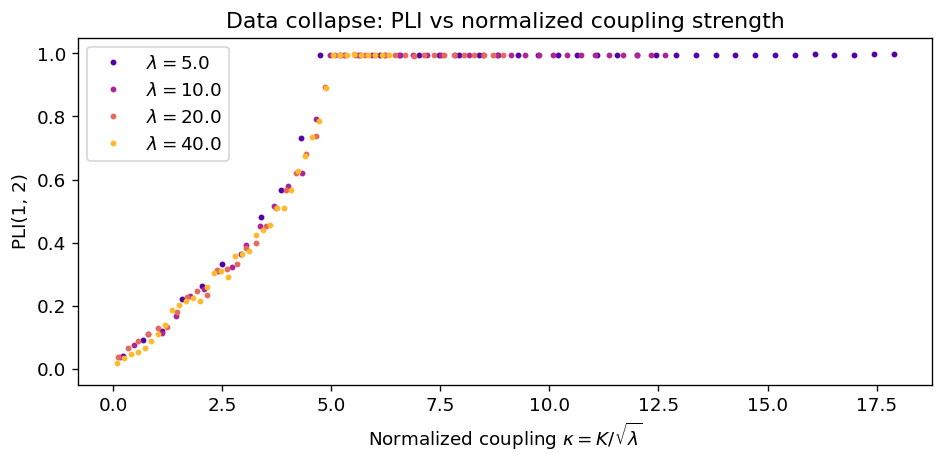

In [30]:
fig, ax = plt.subplots(figsize=(8, 4))

for lam, col in zip([5.0, 10.0, 20.0, 40.0],
                    plt.cm.plasma(np.linspace(0.15, 0.85, 4))):
    K_vals = np.linspace(0.5, 40, 40)
    kappa_vals = K_vals / np.sqrt(lam)
    pli_vals = [pli_12(K, lam) for K in K_vals]
    ax.plot(kappa_vals, pli_vals, "o", ms=2.5, color=col,
            label=rf"$\lambda = {lam}$")

ax.set_xlabel(r"Normalized coupling $\kappa = K / \sqrt{\lambda}$")
ax.set_ylabel("PLI(1, 2)")
ax.set_title("Data collapse: PLI vs normalized coupling strength")
ax.legend()
ax.set_ylim(-0.05, 1.05)
fig.tight_layout()
fig.savefig(FIG_DIR / "06_pli_data_collapse.png", dpi=150, bbox_inches="tight")


## 7. Effect of frequency detuning

We fix $\omega_1 = 10$ Hz and vary $\omega_2$ from 8 to 12 Hz.
Larger frequency mismatch makes it harder for coupling to establish a
consistent phase lag, so PLI should decrease with detuning.

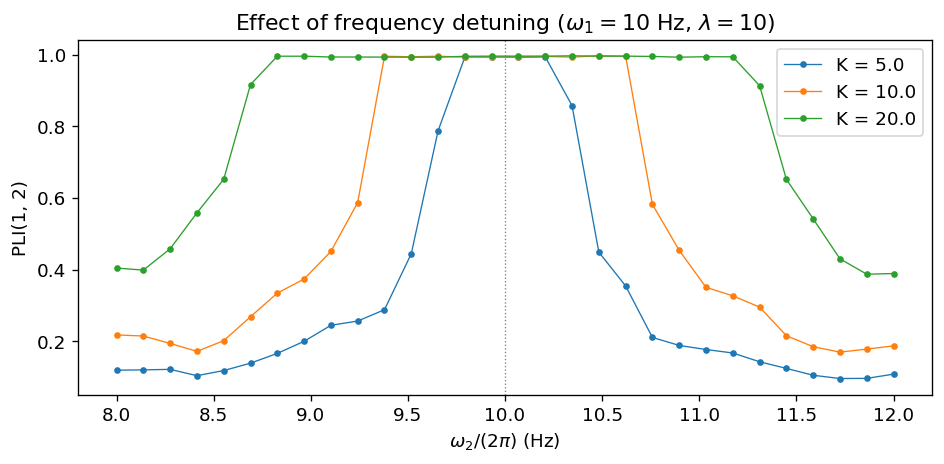

In [31]:
lam = 10.0

fig, ax = plt.subplots(figsize=(8, 4))
omega2_values = np.linspace(8, 12, 30)

for K, col in zip([5.0, 10.0, 20.0], ["C0", "C1", "C2"]):
    pli_detune = [pli_12(K, lam, omega_hz=(10.0, f2)) for f2 in omega2_values]
    ax.plot(omega2_values, pli_detune, "o-", ms=3, lw=0.8,
            color=col, label=f"K = {K}")

ax.axvline(10.0, color="grey", ls=":", lw=0.8)
ax.set_xlabel(r"$\omega_2 / (2\pi)$ (Hz)")
ax.set_ylabel("PLI(1, 2)")
ax.set_title(r"Effect of frequency detuning ($\omega_1 = 10$ Hz, $\lambda = 10$)")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "07_pli_frequency_detuning.png", dpi=150, bbox_inches="tight")


## 8. Effect of edge weight $w$

The structural connectivity weight $w$ and the scaling $C$ enter the coupling
as $K \tanh(C\,w\,x_j)$. We check whether increasing $w$ has a similar effect
to increasing $K$.

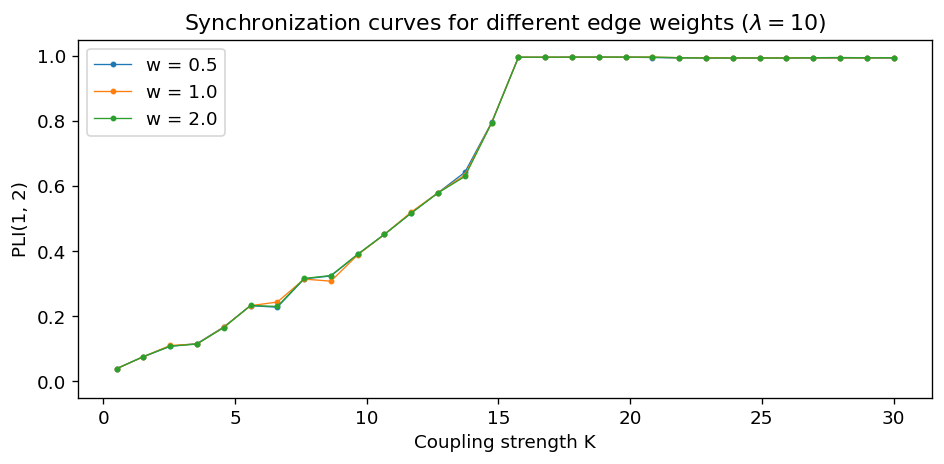

In [32]:
lam = 10.0
K_vals = np.linspace(0.5, 30, 30)

fig, ax = plt.subplots(figsize=(8, 4))
for w, col in zip([0.5, 1.0, 2.0], ["C0", "C1", "C2"]):
    pli_w = [pli_12(K, lam, w=w) for K in K_vals]
    ax.plot(K_vals, pli_w, "o-", ms=2.5, lw=0.8, color=col, label=f"w = {w}")

ax.set_xlabel("Coupling strength K")
ax.set_ylabel("PLI(1, 2)")
ax.set_title(r"Synchronization curves for different edge weights ($\lambda = 10$)")
ax.legend()
ax.set_ylim(-0.05, 1.05)
fig.tight_layout()
fig.savefig(FIG_DIR / "08_pli_edge_weights.png", dpi=150, bbox_inches="tight")


## 9. Variability over random initial conditions

The paper averages over many random initial conditions because different ICs
can lead to different transient dynamics and hence different PLI values for the
same parameters. We show this variability for a range of $K$ values.

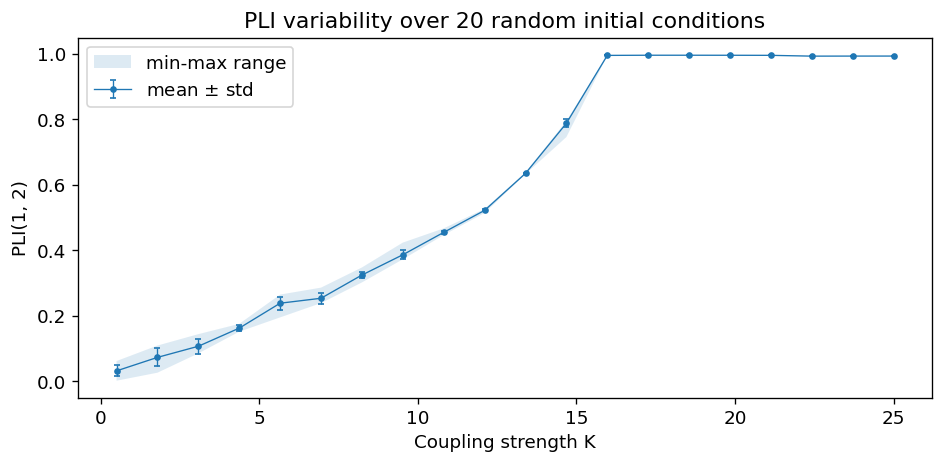

In [33]:
lam = 10.0
K_test = np.linspace(0.5, 25, 20)
n_ics = 20
rng = np.random.default_rng(0)

all_pli = np.zeros((len(K_test), n_ics))
for j, K in enumerate(K_test):
    for ic in range(n_ics):
        z0 = random_initial_conditions(2, rng=rng)
        all_pli[j, ic] = pli_12(K, lam, z0=z0)

fig, ax = plt.subplots(figsize=(8, 4))
ax.errorbar(K_test, all_pli.mean(axis=1), yerr=all_pli.std(axis=1),
            fmt="o-", ms=3, lw=0.8, capsize=2, label="mean $\\pm$ std")
ax.fill_between(K_test, all_pli.min(axis=1), all_pli.max(axis=1),
                alpha=0.15, label="min-max range")
ax.set_xlabel("Coupling strength K")
ax.set_ylabel("PLI(1, 2)")
ax.set_title(f"PLI variability over {n_ics} random initial conditions")
ax.legend()
ax.set_ylim(-0.05, 1.05)
fig.tight_layout()
fig.savefig(FIG_DIR / "09_pli_ic_variability.png", dpi=150, bbox_inches="tight")


## 10. Arnold tongue: synchronization region in $(K, \Delta\omega)$ space

The [Arnold tongue](https://en.wikipedia.org/wiki/Arnold_tongue) is a classic
result in coupled oscillator theory. For two oscillators with frequency detuning
$\Delta\omega = \omega_2 - \omega_1$, there is a V-shaped region in $(K, \Delta\omega)$
space where phase locking occurs. Inside the tongue, PLI is high; outside,
the oscillators drift.

We fix $\omega_1 = 10$ Hz and sweep both $K$ and $\omega_2$.

At zero detuning, high PLI means a fixed phase offset with little coupling; increasing $K$ destroys that offset by synchronizing in-phase, so PLI falls.

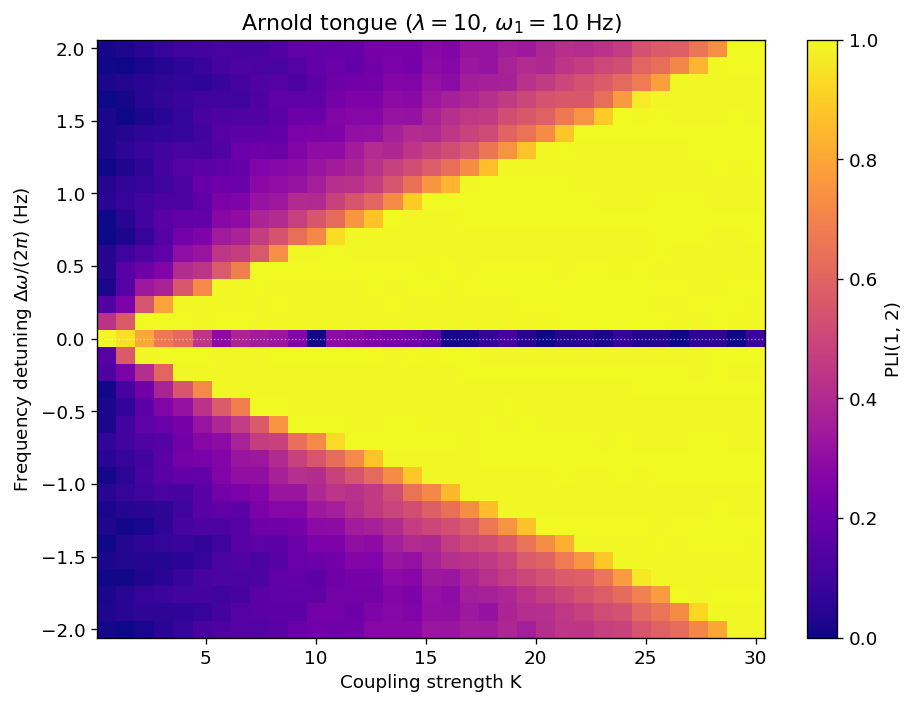

In [35]:
lam = 10.0
omega1 = 10.0
omega2_range = np.linspace(8.0, 12.0, 35)
K_range = np.linspace(0.5, 30, 35)

tongue = np.zeros((len(omega2_range), len(K_range)))
for i, omega2 in enumerate(omega2_range):
    for j, K in enumerate(K_range):
        tongue[i, j] = pli_12(K, lam, omega_hz=(omega1, omega2))

def _lin_bin_edges(c):
    """Linear bin edges so pcolormesh fills to the first/last sample (no inner gaps)."""
    c = np.asarray(c, dtype=float)
    lo = 1.5 * c[0] - 0.5 * c[1]
    hi = 1.5 * c[-1] - 0.5 * c[-2]
    mid = (c[:-1] + c[1:]) / 2
    return np.concatenate([[lo], mid, [hi]])

K_edges = _lin_bin_edges(K_range)
dw = omega2_range - omega1
dw_edges = _lin_bin_edges(dw)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.pcolormesh(K_edges, dw_edges, tongue,
                   cmap="plasma", shading="flat", vmin=0, vmax=1)
ax.set_xlim(K_edges[0], K_edges[-1])
ax.set_ylim(dw_edges[0], dw_edges[-1])
ax.margins(0)
fig.colorbar(im, ax=ax, label="PLI(1, 2)")
ax.set_xlabel("Coupling strength K")
ax.set_ylabel(r"Frequency detuning $\Delta\omega / (2\pi)$ (Hz)")
ax.set_title(r"Arnold tongue ($\lambda = 10$, $\omega_1 = 10$ Hz)")
ax.axhline(0, color="white", ls=":", lw=0.8, alpha=0.5)
fig.tight_layout()
ax.set_xlim(K_edges[0], K_edges[-1])
ax.set_ylim(dw_edges[0], dw_edges[-1])
ax.margins(0)
fig.savefig(FIG_DIR / "10_arnold_tongue.png", dpi=150, bbox_inches="tight")


## 11. Explicit rescaling verification: same $\kappa$, different $(K, \lambda)$

The paper argues that **phase-based** quantities (including PLI) are largely
controlled by $\kappa = K / \sqrt{\lambda}$, not by $K$ and $\lambda$ separately,
especially for **larger** $\lambda$ (see their log–log grids: the invariance along
$K \propto \sqrt{\lambda}$ is clearest there).

Here we fix $\kappa$ and vary $\lambda$ (so $K = \kappa\sqrt{\lambda}$). You should see:

- **Amplitudes** grow like $\sqrt{\lambda}$ (different curve heights in the top panel).
- **PLI** is **approximately** the same across pairs, but **not exactly** identical.

Why PLI can differ a bit between rows: (1) at **small** $\lambda$ the rescaling argument is weaker and **amplitude dynamics** still influence phases; (2) we estimate phase with a **bandpass + Hilbert** pipeline on a **finite** window; (3) **numerical** integration adds tiny errors. As $\lambda$ increases, the bars should **cluster** more tightly — that is the check.

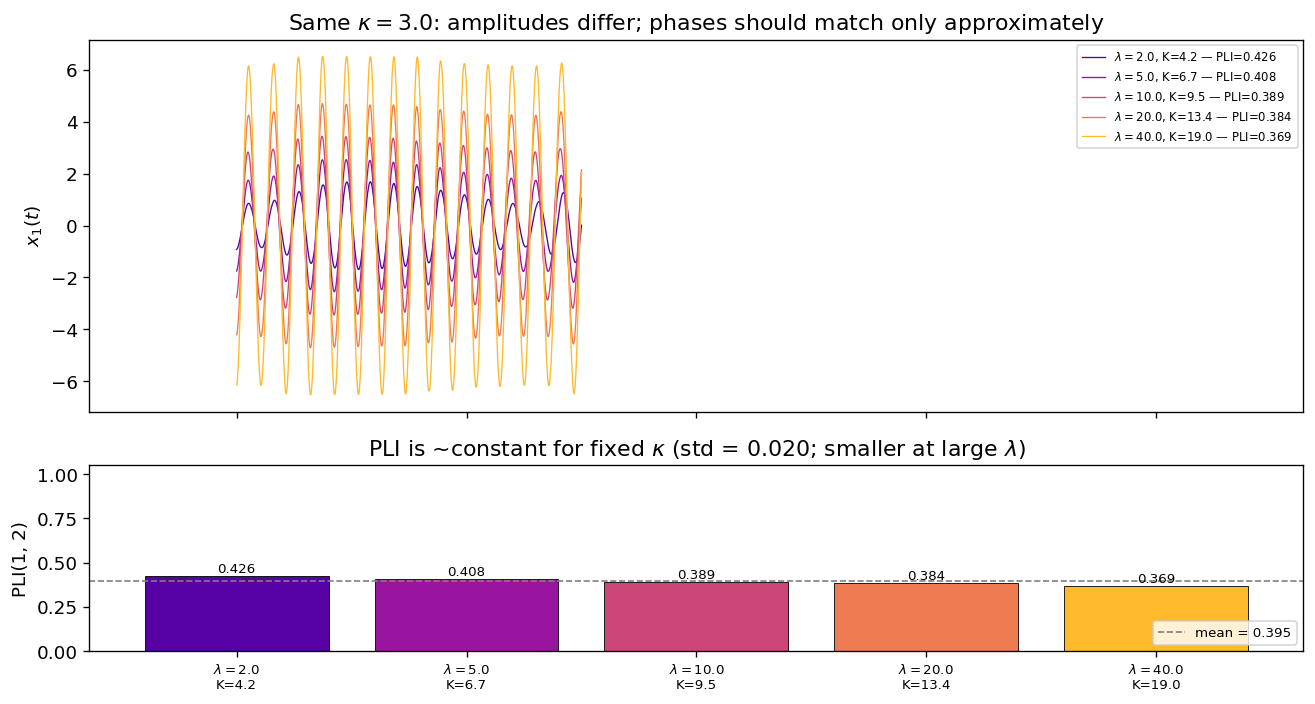

In [36]:
kappa = 3.0
lam_values = [2.0, 5.0, 10.0, 20.0, 40.0]
colors = plt.cm.plasma(np.linspace(0.15, 0.85, len(lam_values)))

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True,
                         gridspec_kw={"height_ratios": [2, 1]})

pli_results = []
for lam, col in zip(lam_values, colors):
    K = kappa * np.sqrt(lam)
    t, x, y_ = simulate_two_node(K, lam)
    phases = compute_phase(x, 1250)
    pli_val = compute_pli(phases)[0, 1]
    pli_results.append(pli_val)

    win = (t >= 0) & (t <= 1.5)
    axes[0].plot(t[win], x[0][win], lw=0.8, color=col,
                 label=rf"$\lambda={lam}$, K={K:.1f} — PLI={pli_val:.3f}")

axes[0].set_ylabel("$x_1(t)$")
axes[0].set_title(rf"Same $\kappa = {kappa}$: amplitudes differ; phases should match only approximately")
axes[0].legend(fontsize=7, loc="upper right")

mean_pli = float(np.mean(pli_results))
std_pli = float(np.std(pli_results))
axes[1].bar(range(len(lam_values)),  pli_results, color=colors, edgecolor="black", lw=0.5)
axes[1].axhline(mean_pli, color="grey", ls="--", lw=1, label=f"mean = {mean_pli:.3f}")
axes[1].set_xticks(range(len(lam_values)))
axes[1].set_xticklabels([rf"$\lambda={lam}$" + f"\nK={kappa*np.sqrt(lam):.1f}"
                         for lam in lam_values], fontsize=8)
axes[1].set_ylabel("PLI(1, 2)")
axes[1].set_ylim(0, 1.05)
axes[1].set_title(rf"PLI is ~constant for fixed $\kappa$ (std = {std_pli:.3f}; smaller at large $\lambda$)")
axes[1].legend(fontsize=8, loc="lower right")

for i, v in enumerate(pli_results):
    axes[1].text(i, v + 0.02, f"{v:.3f}", ha="center", fontsize=8)

fig.tight_layout()
fig.savefig(FIG_DIR / "11_pli_kappa_invariance.png", dpi=150, bbox_inches="tight")


## Summary

| Observation | Details |
|---|---|
| **PLI semantics** | PLI measures phase *asymmetry*, not synchronization. With identical $\omega$, coupling *decreases* PLI; with different $\omega$, coupling *increases* PLI |
| **Synchronization transition** | PLI rises from ~0 to ~1 as $K$ increases (for different $\omega$) |
| **PLI heatmap** | The $(K, \lambda)$ heatmap shows a clear boundary between low and high PLI |
| **Scaling law** | PLI contours approximately follow $K \propto \sqrt{\lambda}$ on log-log axes |
| **Data collapse** | Plotting PLI vs $\kappa = K/\sqrt{\lambda}$ collapses curves from different $\lambda$ |
| **Detuning** | Larger frequency mismatch requires stronger coupling for the same PLI |
| **Edge weight** | Higher $w$ shifts the synchronization transition to lower $K$ |
| **IC variability** | There is meaningful variation in PLI across initial conditions, motivating averaging |
| **Arnold tongue** | The synchronization region in $(K, \Delta\omega)$ space forms the classic V-shape: stronger coupling locks larger detuning |
| **Rescaling verification** | Same $\kappa = K/\sqrt{\lambda}$ gives **similar** PLI (exact invariance is idealised; spread is larger at small $\lambda$) and **different** amplitudes |

